In [1]:
import itertools
import traceback

import networkx as nx
import numpy as np
import pandas as pd
import pyomo.environ as pe

/Users/erickavendanogarcia/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Data Synthesis

First, we construct a random graph. The specified seed yields a fully connected graph.

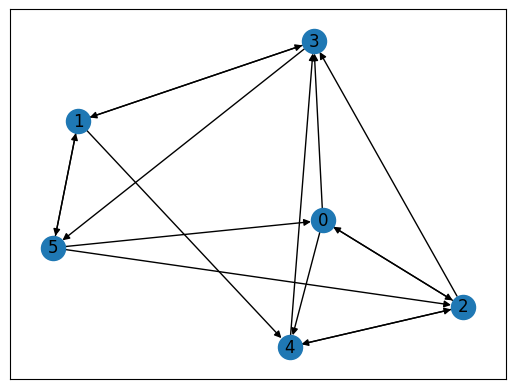

In [2]:
N = 6
p = 0.50
graph = nx.erdos_renyi_graph(N, p, seed=42, directed=True)
nx.draw_networkx(graph)

In [3]:
data = {}
np.random.seed(100)
for edge in graph.edges():
    data[edge] = {'weight': np.random.geometric(0.5)}

In [4]:
df = pd.DataFrame.from_dict(data, orient='index')
df.index.names = ['i', 'j']
display(df)

weight
i j        
0 2       2
  3       1
  4       1
1 3       3
  4       1
  5       1
2 0       2
  3       3
  4       1
3 1       2
  5       4
4 2       1
  3       1
5 0       1
  1       1
  2       6

In [5]:
df_cost = df['weight'].reset_index()\
                      .pivot(index='i', columns='j', values='weight')\
                    .  reindex(index=graph.nodes(), columns=graph.nodes())
display(df_cost)

j,0,1,2,3,4,5
i,,,,,,
0,NaN,NaN,2.0,1.0,1.0,NaN
1,NaN,NaN,NaN,3.0,1.0,1.0
2,2.0,NaN,NaN,3.0,1.0,NaN
3,NaN,2.0,NaN,NaN,NaN,4.0
4,NaN,NaN,1.0,1.0,NaN,NaN
5,1.0,1.0,6.0,NaN,NaN,NaN


## Model Setup
For the sake of demonstration, we purposely built a graph that is not complete. That way we are forced to consider how to build the edge set (which in a complete graph is just the Cartesian product of the node set with itself, perhaps excluding self-loops).

### Attempt 1: Workable, but error prone.

In [6]:
nodes = set(itertools.chain(*df.index))

model = pe.ConcreteModel()
model.nodes = pe.Set(initialize=nodes)
# initialize as Cartesian product of node set with itself
model.edges = pe.Set(initialize=model.nodes*model.nodes)

source (type: set).  This WILL potentially lead to nondeterministic behavior
in Pyomo


In [21]:
nodes

{0, 1, 2, 3, 4, 5}

In [7]:
len(model.edges)

36

### Attempt 2: Incorrect.

In [8]:
nodes = set(itertools.chain(*df.index))

model = pe.ConcreteModel()
model.nodes = pe.Set(initialize=nodes)
# declare as a subset of the Cartesian product
model.edges = pe.Set(within=model.nodes*model.nodes)

source (type: set).  This WILL potentially lead to nondeterministic behavior
in Pyomo


In [9]:
len(model.edges)

0

### Attempt 3: Correct and more robust than Attempt #1.

In [10]:
nodes = set(itertools.chain(*df.index))
edges = set(df.index)

model = pe.ConcreteModel()
model.nodes = pe.Set(initialize=nodes)
# declare as a subset of the Cartesian product, initialize as DataFrame index
model.edges = pe.Set(within=model.nodes*model.nodes, initialize=edges)

source (type: set).  This WILL potentially lead to nondeterministic behavior
in Pyomo


In [11]:
len(model.edges)

16

### Why within? Free error checking

Here, we see that specifying the within keyword for the edge set helps to curate our inputs. To show this, we purposely try to add an edge that is not in the Cartesian product of the node set with itself. Pyomo correctly detects the error and raises an error.

In [12]:
nodes = set(itertools.chain(*df.index))
edges = set(df.index.tolist() + [(0, 1234)])

model = pe.ConcreteModel()
model.nodes = pe.Set(initialize=nodes)

try:
    model.edges = pe.Set(within=model.nodes*model.nodes, initialize=edges)
except ValueError:
    traceback.print_exc()

source (type: set).  This WILL potentially lead to nondeterministic behavior
in Pyomo
ERROR: Constructing component 'edges' from data=None failed:
        ValueError: Cannot add value (0, 1234) to Set edges.
    	The value is not in the domain nodes*nodes


Traceback (most recent call last):
  File "/var/folders/hb/c3zh8bns0mx4nw98_6k7rx8m0000gn/T/ipykernel_21618/2864732377.py", line 8, in <module>
    model.edges = pe.Set(within=model.nodes*model.nodes, initialize=edges)
    ^^^^^^^^^^^
  File "/Users/erickavendanogarcia/anaconda3/lib/python3.11/site-packages/pyomo/core/base/block.py", line 573, in __setattr__
    self.add_component(name, val)
  File "/Users/erickavendanogarcia/anaconda3/lib/python3.11/site-packages/pyomo/core/base/block.py", line 1103, in add_component
    val.construct(data)
  File "/Users/erickavendanogarcia/anaconda3/lib/python3.11/site-packages/pyomo/core/base/disable_methods.py", line 124, in construct
    return base.construct(self, data)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/erickavendanogarcia/anaconda3/lib/python3.11/site-packages/pyomo/core/base/set.py", line 2342, in construct
    self._getitem_when_not_present(index)
  File "/Users/erickavendanogarcia/anaconda3/lib/python3.11/site-packages/pyo

Without the within keyword, Pyomo will accept virtually any immutable object.

In [13]:
nodes = set(itertools.chain(*df.index))
edges = set(df.index.tolist() + [('foo', 'bar')])

model = pe.ConcreteModel()
model.nodes = pe.Set(initialize=nodes)
model.edges = pe.Set(initialize=edges) # no `within` keyword, no sanity check!

source (type: set).  This WILL potentially lead to nondeterministic behavior
in Pyomo
source (type: set).  This WILL potentially lead to nondeterministic behavior
in Pyomo


### Benefits of importing dict- like Data

In [14]:
nodes = set(itertools.chain(*df.index))

model = pe.ConcreteModel()
model.nodes = pe.Set(initialize=nodes)
model.edges = pe.Set(within=model.nodes*model.nodes, initialize=df.index)
# build parameter from table data (nodes * nodes)
model.cost = pe.Param(model.edges, initialize=df_cost.stack().to_dict())

source (type: set).  This WILL potentially lead to nondeterministic behavior
in Pyomo


In [15]:
df_cost.stack().to_dict()

{(0, 2): 2.0,
 (0, 3): 1.0,
 (0, 4): 1.0,
 (1, 3): 3.0,
 (1, 4): 1.0,
 (1, 5): 1.0,
 (2, 0): 2.0,
 (2, 3): 3.0,
 (2, 4): 1.0,
 (3, 1): 2.0,
 (3, 5): 4.0,
 (4, 2): 1.0,
 (4, 3): 1.0,
 (5, 0): 1.0,
 (5, 1): 1.0,
 (5, 2): 6.0}

In [16]:
nodes = set(itertools.chain(*df.index))

model = pe.ConcreteModel()
model.nodes = pe.Set(initialize=nodes)
model.edges = pe.Set(within=model.nodes*model.nodes, initialize=df.index)
# build parameter from flattened data indexed by edge set
model.cost = pe.Param(model.edges, initialize=df['weight'].to_dict())

source (type: set).  This WILL potentially lead to nondeterministic behavior
in Pyomo


In [17]:
df['weight'].to_dict()

{(0, 2): 2,
 (0, 3): 1,
 (0, 4): 1,
 (1, 3): 3,
 (1, 4): 1,
 (1, 5): 1,
 (2, 0): 2,
 (2, 3): 3,
 (2, 4): 1,
 (3, 1): 2,
 (3, 5): 4,
 (4, 2): 1,
 (4, 3): 1,
 (5, 0): 1,
 (5, 1): 1,
 (5, 2): 6}

In [18]:
dict(model.cost)

{(0, 2): 2,
 (0, 3): 1,
 (0, 4): 1,
 (1, 3): 3,
 (1, 4): 1,
 (1, 5): 1,
 (2, 0): 2,
 (2, 3): 3,
 (2, 4): 1,
 (3, 1): 2,
 (3, 5): 4,
 (4, 2): 1,
 (4, 3): 1,
 (5, 0): 1,
 (5, 1): 1,
 (5, 2): 6}